# Federated Learning - Practical C: Analysis
**Dataset:** FashionMNIST | **Strategy:** FedAvg | **Rounds:** 10

Experiments varying number of nodes (5 vs 20) and data partitioner (IID, Dirichlet α=0.1, Pathological 2 classes/client).

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

rounds = list(range(0, 11))

# ── Results from all 6 experiments ──────────────────────────────────────────
results = {
    'small-iid': {
        'label': 'IID · 5 nodes',
        'color': '#2196F3', 'linestyle': '-', 'marker': 'o',
        'accuracy': [0.0986, 0.8167, 0.8501, 0.8644, 0.8762, 0.8803, 0.8861, 0.8897, 0.8938, 0.8995, 0.9023],
        'loss':     [2.3021, 0.5122, 0.4128, 0.3670, 0.3366, 0.3261, 0.3116, 0.3001, 0.2886, 0.2817, 0.2717],
        'train_loss':[None,  0.8395, 0.4860, 0.4137, 0.3725, 0.3413, 0.3210, 0.3029, 0.2908, 0.2767, 0.2681],
    },
    'large-iid': {
        'label': 'IID · 20 nodes',
        'color': '#2196F3', 'linestyle': '--', 'marker': 's',
        'accuracy': [0.1013, 0.7412, 0.7812, 0.8015, 0.8190, 0.8351, 0.8445, 0.8518, 0.8533, 0.8619, 0.8656],
        'loss':     [2.3068, 0.7218, 0.5805, 0.5211, 0.4856, 0.4493, 0.4245, 0.4096, 0.3968, 0.3820, 0.3690],
        'train_loss':[None,  1.4890, 0.7304, 0.6122, 0.5459, 0.5098, 0.4731, 0.4562, 0.4351, 0.4178, 0.4024],
    },
    'small-dirichlet': {
        'label': 'Dirichlet α=0.1 · 5 nodes',
        'color': '#FF9800', 'linestyle': '-', 'marker': 'o',
        'accuracy': [0.1346, 0.8130, 0.8498, 0.8645, 0.8751, 0.8814, 0.8853, 0.8899, 0.8916, 0.8956, 0.8998],
        'loss':     [2.3061, 0.5017, 0.4095, 0.3681, 0.3476, 0.3226, 0.3085, 0.2996, 0.2896, 0.2819, 0.2774],
        'train_loss':[None,  0.8877, 0.4863, 0.4114, 0.3727, 0.3419, 0.3204, 0.3042, 0.2900, 0.2748, 0.2641],
    },
    'large-dirichlet': {
        'label': 'Dirichlet α=0.1 · 20 nodes',
        'color': '#FF9800', 'linestyle': '--', 'marker': 's',
        'accuracy': [0.1730, 0.7169, 0.7631, 0.7950, 0.8190, 0.8343, 0.8427, 0.8476, 0.8533, 0.8602, 0.8636],
        'loss':     [2.3006, 0.7901, 0.6191, 0.5355, 0.4895, 0.4604, 0.4367, 0.4154, 0.4030, 0.3920, 0.3781],
        'train_loss':[None,  1.5084, 0.7788, 0.6338, 0.5591, 0.5195, 0.4890, 0.4617, 0.4442, 0.4230, 0.4108],
    },
    'small-pathological': {
        'label': 'Pathological · 5 nodes',
        'color': '#4CAF50', 'linestyle': '-', 'marker': 'o',
        'accuracy': [0.1375, 0.8192, 0.8541, 0.8698, 0.8753, 0.8810, 0.8883, 0.8904, 0.8924, 0.8980, 0.8984],
        'loss':     [2.2990, 0.4875, 0.4049, 0.3574, 0.3412, 0.3219, 0.3036, 0.2951, 0.2898, 0.2796, 0.2737],
        'train_loss':[None,  0.8373, 0.4753, 0.4048, 0.3594, 0.3355, 0.3125, 0.2957, 0.2808, 0.2694, 0.2570],
    },
    'large-pathological': {
        'label': 'Pathological · 20 nodes',
        'color': '#4CAF50', 'linestyle': '--', 'marker': 's',
        'accuracy': [0.1382, 0.7350, 0.7736, 0.7971, 0.8111, 0.8298, 0.8416, 0.8465, 0.8550, 0.8590, 0.8645],
        'loss':     [2.2983, 0.7400, 0.6002, 0.5358, 0.4967, 0.4619, 0.4407, 0.4231, 0.4031, 0.3902, 0.3781],
        'train_loss':[None,  1.4717, 0.7501, 0.6273, 0.5687, 0.5195, 0.4926, 0.4696, 0.4466, 0.4286, 0.4134],
    },
}

print('Datos cargados correctamente.')
print(f'Experiments: {list(results.keys())}')

Datos cargados correctamente.
Experiments: ['small-iid', 'large-iid', 'small-dirichlet', 'large-dirichlet', 'small-pathological', 'large-pathological']


## 1. Accuracy global a lo largo de las rondas (todos los experimentos)

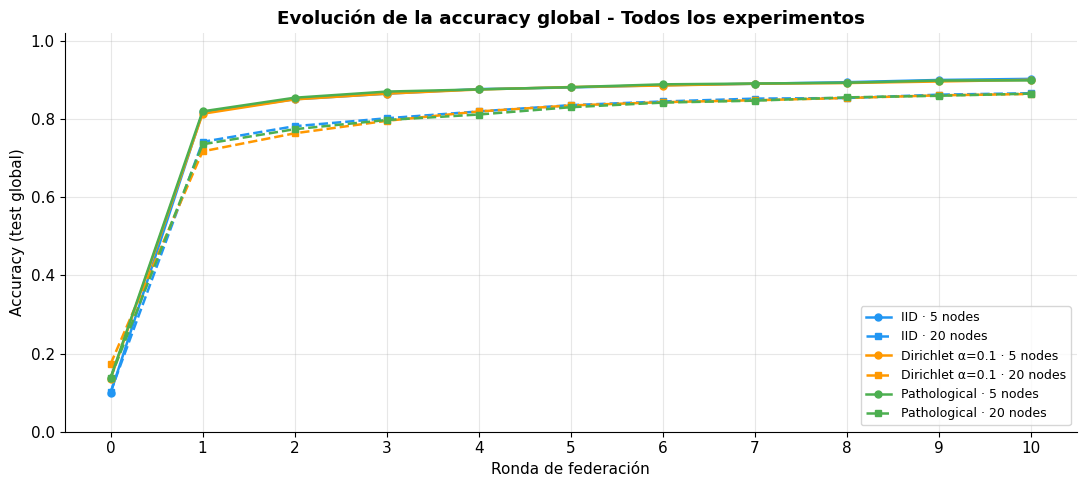

Guardado: plot_accuracy_all.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

for key, exp in results.items():
    ax.plot(rounds, exp['accuracy'],
            label=exp['label'], color=exp['color'],
            linestyle=exp['linestyle'], marker=exp['marker'],
            markersize=5, linewidth=1.8)

ax.set_xlabel('Ronda de federación')
ax.set_ylabel('Accuracy (test global)')
ax.set_title('Evolución de la accuracy global - Todos los experimentos', fontweight='bold')
ax.set_xticks(rounds)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('plot_accuracy_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: plot_accuracy_all.png')

## 2. Loss global a lo largo de las rondas

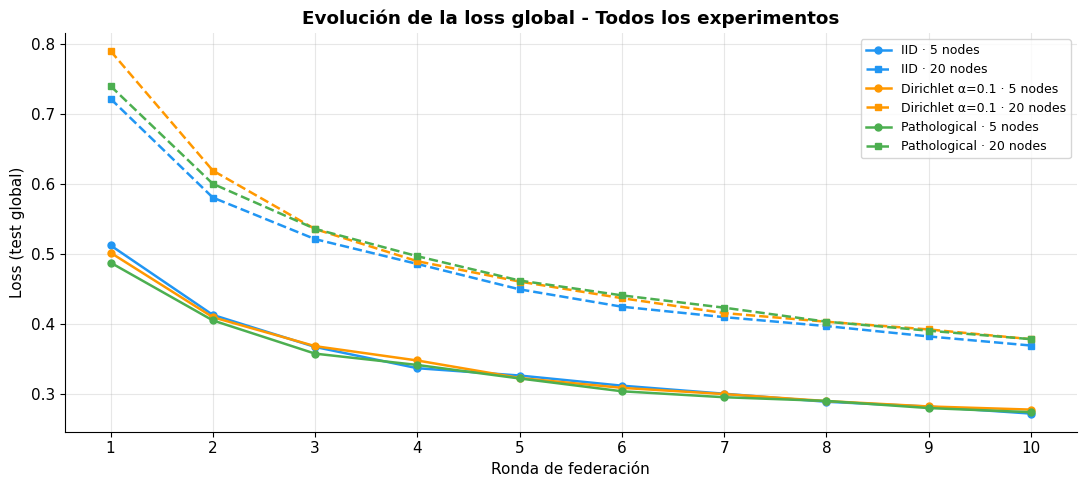

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for key, exp in results.items():
    ax.plot(rounds[1:], exp['loss'][1:],
            label=exp['label'], color=exp['color'],
            linestyle=exp['linestyle'], marker=exp['marker'],
            markersize=5, linewidth=1.8)

ax.set_xlabel('Ronda de federación')
ax.set_ylabel('Loss (test global)')
ax.set_title('Evolución de la loss global - Todos los experimentos', fontweight='bold')
ax.set_xticks(rounds[1:])
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('plot_loss_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparativa por partitioner (5 vs 20 nodos)

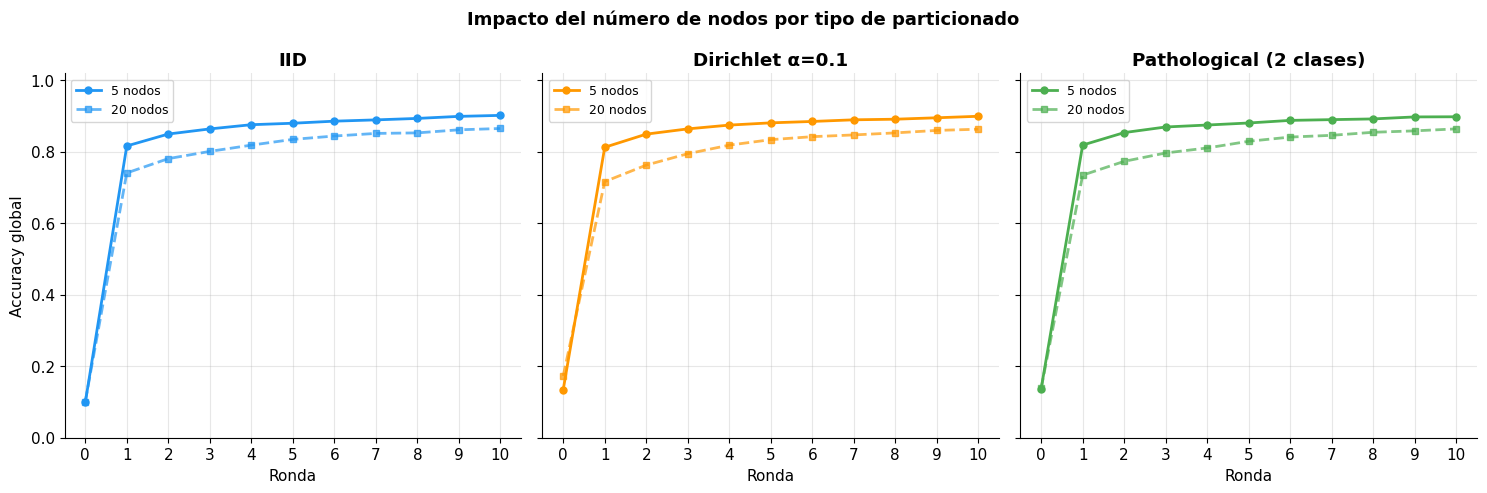

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

pairs = [
    ('small-iid', 'large-iid', 'IID'),
    ('small-dirichlet', 'large-dirichlet', 'Dirichlet α=0.1'),
    ('small-pathological', 'large-pathological', 'Pathological (2 clases)'),
]

for ax, (small_key, large_key, title) in zip(axes, pairs):
    color = results[small_key]['color']
    ax.plot(rounds, results[small_key]['accuracy'],
            label='5 nodos', color=color, linestyle='-', marker='o', markersize=5, linewidth=2)
    ax.plot(rounds, results[large_key]['accuracy'],
            label='20 nodos', color=color, linestyle='--', marker='s', markersize=5, linewidth=2, alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ronda')
    ax.set_xticks(rounds)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Accuracy global')
fig.suptitle('Impacto del número de nodos por tipo de particionado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_nodes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Accuracy final - Gráfico de barras

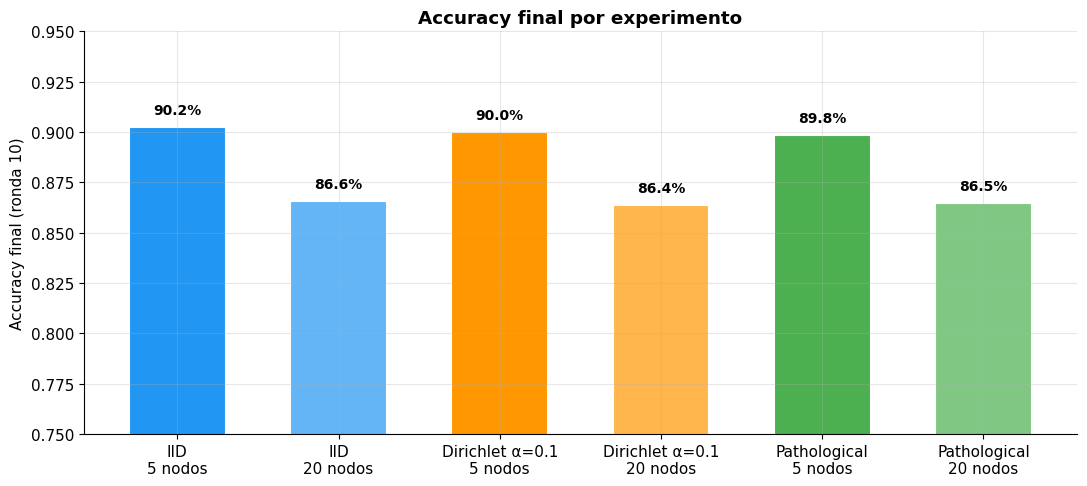

In [6]:
labels = ['IID\n5 nodos', 'IID\n20 nodos',
          'Dirichlet α=0.1\n5 nodos', 'Dirichlet α=0.1\n20 nodos',
          'Pathological\n5 nodos', 'Pathological\n20 nodos']
keys = ['small-iid', 'large-iid', 'small-dirichlet', 'large-dirichlet',
        'small-pathological', 'large-pathological']
final_acc = [results[k]['accuracy'][-1] for k in keys]
colors = ['#2196F3', '#64B5F6', '#FF9800', '#FFB74D', '#4CAF50', '#81C784']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, final_acc, color=colors, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, final_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.75, 0.95)
ax.set_ylabel('Accuracy final (ronda 10)')
ax.set_title('Accuracy final por experimento', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_final_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train loss por experimento

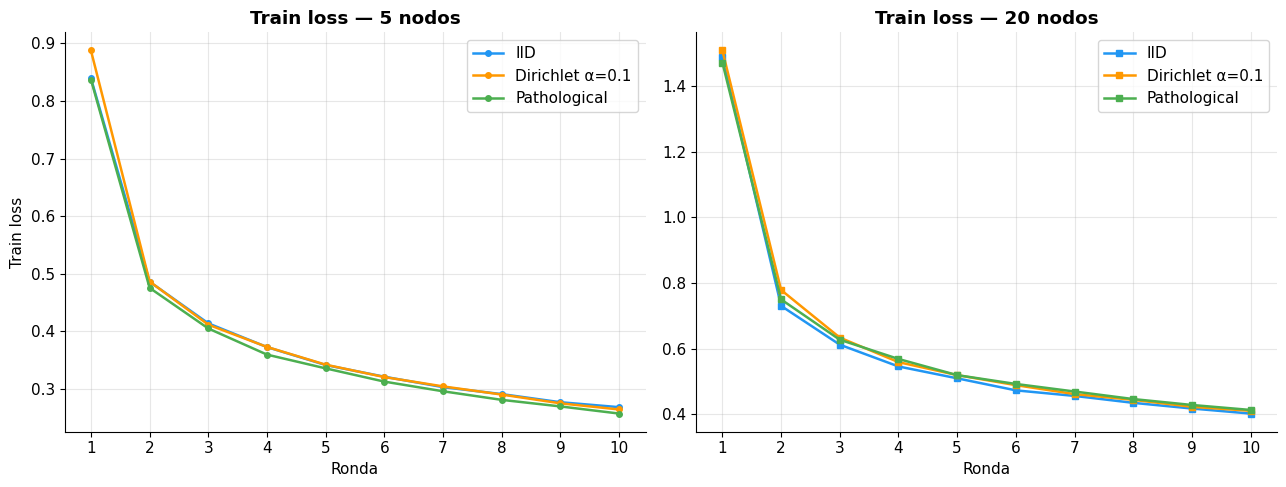

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 5 nodos
for key in ['small-iid', 'small-dirichlet', 'small-pathological']:
    exp = results[key]
    train = [v for v in exp['train_loss'] if v is not None]
    axes[0].plot(rounds[1:], train, label=exp['label'].split(' · ')[0],
                 color=exp['color'], marker='o', markersize=4, linewidth=1.8)
axes[0].set_title('Train loss — 5 nodos', fontweight='bold')
axes[0].set_xlabel('Ronda'); axes[0].set_ylabel('Train loss')
axes[0].set_xticks(rounds[1:])
axes[0].legend()

# 20 nodos
for key in ['large-iid', 'large-dirichlet', 'large-pathological']:
    exp = results[key]
    train = [v for v in exp['train_loss'] if v is not None]
    axes[1].plot(rounds[1:], train, label=exp['label'].split(' · ')[0],
                 color=exp['color'], marker='s', markersize=4, linewidth=1.8)
axes[1].set_title('Train loss — 20 nodos', fontweight='bold')
axes[1].set_xlabel('Ronda')
axes[1].set_xticks(rounds[1:])
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resumen numérico

In [9]:
header = f"{'Experimento':<35} {'Acc. R1':>8} {'Acc. R5':>8} {'Acc. R10':>9} {'Loss R10':>9}"
print(header)
print('-' * 72)
for key, exp in results.items():
    label = exp['label']
    a1  = exp['accuracy'][1]
    a5  = exp['accuracy'][5]
    a10 = exp['accuracy'][10]
    l10 = exp['loss'][10]
    print(f"{label:<35} {a1:>8.4f} {a5:>8.4f} {a10:>9.4f} {l10:>9.4f}")

print('\n--- Insights ---')
print('Con 5 nodos:  IID=90.2%, Dirichlet=90.0%, Pathological=89.8% -> heterogeneidad apenas afecta')
print('Con 20 nodos: todos rondan 86-87% -> mas nodos = menos datos/cliente = convergencia mas lenta')
print('El gap 5 vs 20 nodos es ~3-4% en las 10 primeras rondas')
print('Convergencia mas rapida con 5 nodos (la curva se aplana antes de ronda 5)')

Experimento                          Acc. R1  Acc. R5  Acc. R10  Loss R10
------------------------------------------------------------------------
IID · 5 nodes                         0.8167   0.8803    0.9023    0.2717
IID · 20 nodes                        0.7412   0.8351    0.8656    0.3690
Dirichlet α=0.1 · 5 nodes             0.8130   0.8814    0.8998    0.2774
Dirichlet α=0.1 · 20 nodes            0.7169   0.8343    0.8636    0.3781
Pathological · 5 nodes                0.8192   0.8810    0.8984    0.2737
Pathological · 20 nodes               0.7350   0.8298    0.8645    0.3781

--- Insights ---
Con 5 nodos:  IID=90.2%, Dirichlet=90.0%, Pathological=89.8% -> heterogeneidad apenas afecta
Con 20 nodos: todos rondan 86-87% -> mas nodos = menos datos/cliente = convergencia mas lenta
El gap 5 vs 20 nodos es ~3-4% en las 10 primeras rondas
Convergencia mas rapida con 5 nodos (la curva se aplana antes de ronda 5)
